# Capture24 Single-Participant Processing Inspection

这个 notebook 用来先在单个 Capture24 participant 文件上验证处理流程，暂不写入正式 `/Volumes/Felix_Backups/Processed`。

检查重点：

- 原始时间间隔是否严格稳定 `10 ms`
- 如果原始时间轴不完全稳定，如何报错并跳过该 participant
- 时间轴稳定时如何直接处理，不做 bin 筛选，不做插值
- 如何按 `activity` 一致性筛选 segment
- 如何生成 `[T, 4] float32` 的 `acc` 数组和 manifest entry 预览

当前 notebook 不依赖 `pandas`。如果安装了 `matplotlib`，会额外画图；没有安装则跳过画图。

## 0. Imports And Config

`MAX_ROWS` 用于调试阶段限制读取行数。设为 `None` 时读取完整 participant 文件。

In [14]:
from pathlib import Path
from datetime import datetime
import csv
import gzip
import json
from collections import Counter

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

DATASET_ROOT = Path('/Users/zixuanwang/Downloads/capture24')
PARTICIPANT_FILE = DATASET_ROOT / 'P001.csv.gz'
LABEL_DICT_PATH = DATASET_ROOT / 'annotation-label-dictionary.csv'

SRC = 'capture24'
DEVICE = 'watch'
FREQ = 100.0
PERIOD_MS = 1000.0 / FREQ
G_TO_MPS2 = 9.80665

MODES = {
    '10s': {'frames': 1000, 'duration_sec': 10.0},
    '1000f': {'frames': 1000, 'duration_sec': 10.0},
}

# For fast first inspection, keep this at 300_000. Set to None to read the whole participant file.
MAX_ROWS = 300_000

print('dataset root:', DATASET_ROOT)
print('participant file:', PARTICIPANT_FILE)
print('max rows:', MAX_ROWS)
print('matplotlib available:', HAS_MATPLOTLIB)

dataset root: /Users/zixuanwang/Downloads/capture24
participant file: /Users/zixuanwang/Downloads/capture24/P001.csv.gz
max rows: 300000
matplotlib available: True


## 1. Discover Files And Load Label Dictionary

In [15]:
participant_files = sorted(DATASET_ROOT.glob('P*.csv.gz'))
print('participant files:', len(participant_files))
print('first files:', [p.name for p in participant_files[:5]])
print('label dict exists:', LABEL_DICT_PATH.exists())

def load_label_dictionary(path: Path) -> dict[str, dict]:
    mapping = {}
    with path.open('r', encoding='utf-8', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            annotation = row['annotation']
            mapping[annotation] = {
                'activity': row['label:WillettsSpecific2018'],
                'raw': row,
            }
    return mapping

label_dict = load_label_dictionary(LABEL_DICT_PATH)
activity_counts = Counter(v['activity'] for v in label_dict.values())
print('label dictionary rows:', len(label_dict))
print('activities:', sorted(activity_counts))
print('activity counts in dictionary:', dict(sorted(activity_counts.items())))

participant files: 151
first files: ['P001.csv.gz', 'P002.csv.gz', 'P003.csv.gz', 'P004.csv.gz', 'P005.csv.gz']
label dict exists: True
label dictionary rows: 206
activities: ['bicycling', 'household-chores', 'manual-work', 'mixed-activity', 'sitting', 'sleep', 'sports', 'standing', 'vehicle', 'walking']
activity counts in dictionary: {'bicycling': 1, 'household-chores': 24, 'manual-work': 15, 'mixed-activity': 31, 'sitting': 59, 'sleep': 1, 'sports': 14, 'standing': 38, 'vehicle': 5, 'walking': 18}


## 2. Read One Participant

读取 `time/x/y/z/annotation`。为降低内存占用，annotation 会编码成整数 ID，后续通过 `id_to_annotation` 还原。

In [16]:
class SkipParticipant(Exception):
    pass

def parse_time_ms(value: str, base) -> tuple[float, datetime]:
    dt = datetime.fromisoformat(value)
    if base is None:
        base = dt
    return (dt - base).total_seconds() * 1000.0, base

def read_capture24_file(path: Path, max_rows=None) -> dict:
    times = []
    acc = []
    ann_ids = []
    annotation_to_id = {}
    id_to_annotation = []
    base_time = None
    dropped_non_finite = 0

    with gzip.open(path, 'rt', encoding='utf-8', newline='') as f:
        reader = csv.DictReader(f)
        expected = ['time', 'x', 'y', 'z', 'annotation']
        if reader.fieldnames != expected:
            raise SkipParticipant(f'unexpected header: {reader.fieldnames}')

        for i, row in enumerate(reader):
            if max_rows is not None and i >= max_rows:
                break
            try:
                t_ms, base_time = parse_time_ms(row['time'], base_time)
                xyz_g = [float(row['x']), float(row['y']), float(row['z'])]
            except ValueError as exc:
                raise SkipParticipant(f'cannot parse row {i}: {exc}') from exc

            if not np.all(np.isfinite(xyz_g)):
                dropped_non_finite += 1
                continue

            annotation = row['annotation']
            if annotation not in annotation_to_id:
                annotation_to_id[annotation] = len(id_to_annotation)
                id_to_annotation.append(annotation)

            times.append(t_ms)
            acc.append(xyz_g)
            ann_ids.append(annotation_to_id[annotation])

    if len(times) < 2:
        raise SkipParticipant('not enough rows')

    return {
        'time_ms': np.asarray(times, dtype=np.float64),
        'acc_g': np.asarray(acc, dtype=np.float32),
        'ann_ids': np.asarray(ann_ids, dtype=np.int32),
        'id_to_annotation': id_to_annotation,
        'dropped_non_finite': dropped_non_finite,
        'base_time': base_time,
    }

raw = read_capture24_file(PARTICIPANT_FILE, MAX_ROWS)
time_ms = raw['time_ms']
acc_g = raw['acc_g']
ann_ids = raw['ann_ids']
id_to_annotation = raw['id_to_annotation']

print('rows loaded:', len(time_ms))
print('base time:', raw['base_time'])
print('dropped non-finite rows:', raw['dropped_non_finite'])
print('unique annotations in loaded rows:', len(id_to_annotation))
print('time range ms:', float(time_ms[0]), float(time_ms[-1]))
print('acc_g shape/dtype:', acc_g.shape, acc_g.dtype)
print('first annotations:', id_to_annotation[:5])

rows loaded: 300000
base time: 2016-11-13 02:18:00
dropped non-finite rows: 0
unique annotations in loaded rows: 1
time range ms: 0.0 2999990.0
acc_g shape/dtype: (300000, 3) float32
first annotations: ['7030 sleeping;MET 0.95']


## 3. Check Whether Raw Time Is Already Strict 10 ms

这个代码块专门回答：原始数据是不是已经稳定 `10 ms`。如果不是全局稳定 10ms，当前处理策略是直接跳过该 participant，不做 bin 筛选，也不做插值。

In [17]:
def summarize_dt(time_ms: np.ndarray) -> dict:
    dt = np.diff(time_ms)
    rounded = np.round(dt, 6)
    counts = Counter(rounded.tolist())
    top = counts.most_common(10)
    return {
        'num_intervals': len(dt),
        'min_dt': float(np.min(dt)),
        'median_dt': float(np.median(dt)),
        'mean_dt': float(np.mean(dt)),
        'max_dt': float(np.max(dt)),
        'all_exact_10ms': bool(np.allclose(dt, PERIOD_MS, rtol=0.0, atol=1e-6)),
        'num_not_10ms': int(np.sum(~np.isclose(dt, PERIOD_MS, rtol=0.0, atol=1e-6))),
        'top_dt_counts': top,
    }

dt_summary = summarize_dt(time_ms)
print(json.dumps(dt_summary, indent=2, ensure_ascii=False))

if not dt_summary['all_exact_10ms']:
    raise SkipParticipant('raw time axis is not strictly stable at 10 ms')

print('Raw time axis is strictly stable at 10 ms for the loaded range; continue without bin filtering or interpolation.')

{
  "num_intervals": 299999,
  "min_dt": 9.99999999976717,
  "median_dt": 10.0,
  "mean_dt": 10.0,
  "max_dt": 10.00000000023283,
  "all_exact_10ms": true,
  "num_not_10ms": 0,
  "top_dt_counts": [
    [
      10.0,
      299999
    ]
  ]
}
Raw time axis is strictly stable at 10 ms for the loaded range; continue without bin filtering or interpolation.


## 4. Keep Original Order

Capture24 当前策略不排序、不去重。时间轴必须在原始文件顺序下已经稳定 `10 ms`。如果存在乱序、重复时间戳或缺帧，前面的 `dt == 10 ms` 检查会失败并跳过该 participant。

In [18]:
print('original row order preserved')
print('no sorting, no deduplication')
print('rows:', len(time_ms))
print('dt check already passed:', dt_summary['all_exact_10ms'])

original row order preserved
no sorting, no deduplication
rows: 300000
dt check already passed: True


## 7. Convert Units And Use Raw Stable 100 Hz Time Axis

原始时间轴已经通过全局稳定 10ms 检查，因此这里直接使用原始数据，不做插值。为了复用后续代码，变量名仍使用 `target_t` 和 `acc_processed`。

In [19]:
acc_mps2 = (acc_g.astype(np.float64) * G_TO_MPS2).astype(np.float32)
target_t = time_ms
acc_processed = acc_mps2
processing_method = 'direct_no_interpolation'

target_dt = np.diff(target_t)
print('processing method:', processing_method)
print('target frames:', len(target_t))
print('acc_processed shape/dtype:', acc_processed.shape, acc_processed.dtype)
print('target dt min/median/max:', float(np.min(target_dt)), float(np.median(target_dt)), float(np.max(target_dt)))
print('target all 10ms:', bool(np.allclose(target_dt, PERIOD_MS, rtol=0.0, atol=1e-6)))
print('acc m/s^2 min/max:', float(np.min(acc_processed)), float(np.max(acc_processed)))

processing method: direct_no_interpolation
target frames: 300000
acc_processed shape/dtype: (300000, 3) float32
target dt min/median/max: 9.99999999976717 10.0 10.00000000023283
target all 10ms: True
acc m/s^2 min/max: -19.57539939880371 13.539608001708984


## 8. Raw Annotation Ranges

当前 `target_t` 就是原始稳定时间轴。segment 标签检查直接使用该窗口覆盖到的原始 annotation。

In [20]:
def raw_slice_for_target_segment(time_ms: np.ndarray, start_time: float, end_time: float) -> slice:
    left = np.searchsorted(time_ms, start_time, side='left')
    right = np.searchsorted(time_ms, end_time, side='right')
    return slice(left, right)

example_slice = raw_slice_for_target_segment(time_ms, target_t[0], target_t[999])
print('example raw slice:', example_slice)
print('example raw rows:', example_slice.stop - example_slice.start)

example raw slice: slice(0, 1000, None)
example raw rows: 1000


## 9. Segment Label Check

segment 内 annotation 可以多个，但它们必须全部非空、能映射，并且映射后的 `activity` 只有一个。

In [21]:
def unique_annotations_in_first_seen_order(ids: np.ndarray, id_to_annotation: list[str]) -> list[str]:
    seen = set()
    annotations = []
    for ann_id in ids:
        ann = id_to_annotation[int(ann_id)]
        if ann not in seen:
            seen.add(ann)
            annotations.append(ann)
    return annotations

def segment_label(annotations: list[str], label_dict: dict[str, dict]):
    if not annotations:
        return False, None, 'no raw annotations in segment range'
    if any(a == '' for a in annotations):
        return False, None, 'empty annotation'
    missing = [a for a in annotations if a not in label_dict]
    if missing:
        return False, None, 'unknown annotation'
    activities = []
    seen_activity = set()
    for ann in annotations:
        activity = label_dict[ann]['activity']
        if activity not in seen_activity:
            seen_activity.add(activity)
            activities.append(activity)
    if len(activities) != 1:
        return False, None, 'multiple activities'
    return True, {'activity': activities[0], 'annotations': annotations}, None

def inspect_candidate_segment(mode: str, segment_index: int = 0) -> dict:
    frames = MODES[mode]['frames']
    start = segment_index * frames
    end = start + frames
    if end > len(target_t):
        raise IndexError('segment outside target range')
    start_time = target_t[start]
    end_time = target_t[end - 1]
    raw_sl = raw_slice_for_target_segment(time_ms, start_time, end_time)
    annotations = unique_annotations_in_first_seen_order(ann_ids[raw_sl], id_to_annotation)
    label_ok, label, reason = segment_label(annotations, label_dict)
    return {
        'mode': mode,
        'segment_index': int(segment_index),
        'target_start': int(start),
        'target_end': int(end),
        'start_time_ms': float(start_time),
        'end_time_ms': float(end_time),
        'raw_rows_in_range': int(raw_sl.stop - raw_sl.start),
        'label_ok': label_ok,
        'label': label,
        'reject_reason': reason,
        'num_annotations': len(annotations),
        'annotations_preview': annotations[:5],
    }

first_segment = inspect_candidate_segment('10s', 0)
print(json.dumps(first_segment, ensure_ascii=False, indent=2)[:5000])

{
  "mode": "10s",
  "segment_index": 0,
  "target_start": 0,
  "target_end": 1000,
  "start_time_ms": 0.0,
  "end_time_ms": 9990.0,
  "raw_rows_in_range": 1000,
  "label_ok": true,
  "label": {
    "activity": "sleep",
    "annotations": [
      "7030 sleeping;MET 0.95"
    ]
  },
  "reject_reason": null,
  "num_annotations": 1,
  "annotations_preview": [
    "7030 sleeping;MET 0.95"
  ]
}


## 10. Count Valid Segments For Loaded Range

In [22]:
def count_segments(mode: str) -> dict:
    frames = MODES[mode]['frames']
    stats = Counter()
    labels = Counter()
    examples = []
    for start in range(0, len(target_t) - frames + 1, frames):
        end = start + frames
        stats['candidate'] += 1
        raw_sl = raw_slice_for_target_segment(time_ms, target_t[start], target_t[end - 1])
        annotations = unique_annotations_in_first_seen_order(ann_ids[raw_sl], id_to_annotation)
        ok, label, reason = segment_label(annotations, label_dict)
        if not ok:
            stats[f'reject_{reason}'] += 1
            continue
        stats['saved'] += 1
        labels[label['activity']] += 1
        if len(examples) < 5:
            examples.append({'start': start, 'label': label})
    return {'stats': dict(stats), 'labels': dict(sorted(labels.items())), 'examples': examples}

for mode in MODES:
    result = count_segments(mode)
    print('\nMODE', mode)
    print(json.dumps(result, ensure_ascii=False, indent=2)[:5000])


MODE 10s
{
  "stats": {
    "candidate": 300,
    "saved": 300
  },
  "labels": {
    "sleep": 300
  },
  "examples": [
    {
      "start": 0,
      "label": {
        "activity": "sleep",
        "annotations": [
          "7030 sleeping;MET 0.95"
        ]
      }
    },
    {
      "start": 1000,
      "label": {
        "activity": "sleep",
        "annotations": [
          "7030 sleeping;MET 0.95"
        ]
      }
    },
    {
      "start": 2000,
      "label": {
        "activity": "sleep",
        "annotations": [
          "7030 sleeping;MET 0.95"
        ]
      }
    },
    {
      "start": 3000,
      "label": {
        "activity": "sleep",
        "annotations": [
          "7030 sleeping;MET 0.95"
        ]
      }
    },
    {
      "start": 4000,
      "label": {
        "activity": "sleep",
        "annotations": [
          "7030 sleeping;MET 0.95"
        ]
      }
    }
  ]
}

MODE 1000f
{
  "stats": {
    "candidate": 300,
    "saved": 300
  },
  "labels": {
  

## 11. Build One NPZ Array And Manifest Entry Preview

In [23]:
def build_acc_array(target_t: np.ndarray, acc_processed: np.ndarray, start: int, end: int) -> np.ndarray:
    local_t = target_t[start:end] - target_t[start]
    return np.column_stack([local_t, acc_processed[start:end]]).astype(np.float32)

def acc_array_is_valid(acc: np.ndarray, frames: int) -> bool:
    return (
        acc.shape == (frames, 4)
        and acc.dtype == np.float32
        and acc[0, 0] == 0.0
        and np.allclose(np.diff(acc[:, 0]), PERIOD_MS, rtol=0.0, atol=1e-6)
        and np.all(np.isfinite(acc))
    )

def find_first_saved_segment(mode: str) -> tuple[int, dict]:
    frames = MODES[mode]['frames']
    for start in range(0, len(target_t) - frames + 1, frames):
        end = start + frames
        raw_sl = raw_slice_for_target_segment(time_ms, target_t[start], target_t[end - 1])
        annotations = unique_annotations_in_first_seen_order(ann_ids[raw_sl], id_to_annotation)
        ok, label, reason = segment_label(annotations, label_dict)
        if ok:
            return start, label
    raise SkipParticipant(f'no saved segment for {mode}')

MODE = '10s'
start, label = find_first_saved_segment(MODE)
end = start + MODES[MODE]['frames']
acc_seg = build_acc_array(target_t, acc_processed, start, end)

entry = {
    'dir': f'sources/{SRC}/segments/{MODE}/{DEVICE}/00000001.npz',
    'src': SRC,
    'device': DEVICE,
    'freq': FREQ,
    'mode': MODE,
    'num_frames': MODES[MODE]['frames'],
    'duration_sec': MODES[MODE]['duration_sec'],
    'has_timestamp': True,
    'has_gyro': False,
    'label': label,
}

print('first saved start:', start)
print('acc shape/dtype:', acc_seg.shape, acc_seg.dtype)
print('acc valid:', acc_array_is_valid(acc_seg, MODES[MODE]['frames']))
print('time first/last:', float(acc_seg[0, 0]), float(acc_seg[-1, 0]))
print('time dt unique:', np.unique(np.diff(acc_seg[:, 0]))[:10])
print('npz keys would be: acc only')
print(json.dumps(entry, ensure_ascii=False, indent=2)[:5000])

first saved start: 0
acc shape/dtype: (1000, 4) float32
acc valid: True
time first/last: 0.0 9990.0
time dt unique: [10.]
npz keys would be: acc only
{
  "dir": "sources/capture24/segments/10s/watch/00000001.npz",
  "src": "capture24",
  "device": "watch",
  "freq": 100.0,
  "mode": "10s",
  "num_frames": 1000,
  "duration_sec": 10.0,
  "has_timestamp": true,
  "has_gyro": false,
  "label": {
    "activity": "sleep",
    "annotations": [
      "7030 sleeping;MET 0.95"
    ]
  }
}


## 12. Optional Plot

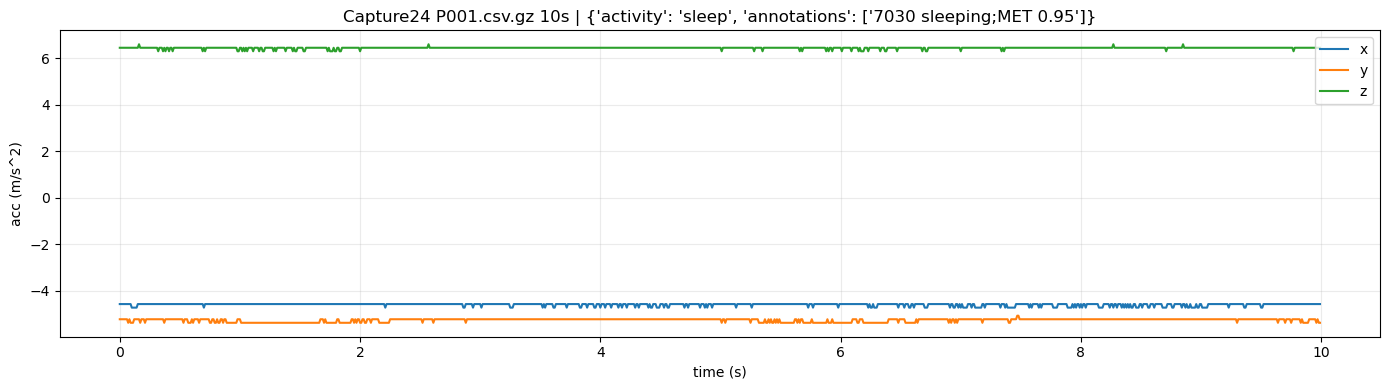

In [24]:
if not HAS_MATPLOTLIB:
    print('matplotlib is not installed; skip plotting. Install it with: %pip install matplotlib')
else:
    t = acc_seg[:, 0] / 1000.0
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(t, acc_seg[:, 1], label='x')
    ax.plot(t, acc_seg[:, 2], label='y')
    ax.plot(t, acc_seg[:, 3], label='z')
    ax.set_title(f'Capture24 {PARTICIPANT_FILE.name} {MODE} | {label}')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('acc (m/s^2)')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()